# Week 2 – Day 3: XGBoost Regression Baseline

This notebook trains an XGBoost regression model for real-estate price prediction.

The model uses the baseline tabular features prepared during Week 2 and provides a stronger nonlinear benchmark against the Linear Regression model developed on Day 2.

## Objectives

- Load the finalized Week 2 baseline dataset.
- Reuse the same train/test split as Linear Regression.
- Train an XGBoost Regressor.
- Generate holdout predictions.
- Inspect prediction errors.
- Compare the model output with the Linear Regression baseline.
- Save the trained XGBoost model for subsequent evaluation.

In [1]:
import os
import sys
import joblib
import numpy as np
import pandas as pd

from xgboost import XGBRegressor

from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error

print("XGBoost imported successfully.")

XGBoost imported successfully.


In [2]:
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))

DATA_DIR = os.path.join(PROJECT_ROOT,"data","processed","week-2")

MODEL_DIR = os.path.join(PROJECT_ROOT,"models")

os.makedirs(MODEL_DIR, exist_ok=True)

print("Project root:")
print(PROJECT_ROOT)

print("\nData directory:")
print(DATA_DIR)

print("\nModel directory:")
print(MODEL_DIR)

Project root:
e:\AARAV\Infotact-DS-ML\Project-3-Geospatial-Valuation

Data directory:
e:\AARAV\Infotact-DS-ML\Project-3-Geospatial-Valuation\data\processed\week-2

Model directory:
e:\AARAV\Infotact-DS-ML\Project-3-Geospatial-Valuation\models


In [3]:
X_train = pd.read_csv(os.path.join(DATA_DIR, "X_train.csv"))
X_test = pd.read_csv(os.path.join(DATA_DIR, "X_test.csv"))
y_train = pd.read_csv(os.path.join(DATA_DIR, "y_train.csv")).squeeze()
y_test = pd.read_csv(os.path.join(DATA_DIR, "y_test.csv")).squeeze()

print("X_train shape:", X_train.shape)
print("X_test shape :", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape :", y_test.shape)

X_train shape: (17277, 15)
X_test shape : (4320, 15)
y_train shape: (17277,)
y_test shape : (4320,)


In [4]:
print("Training features:")
print(list(X_train.columns))

print("\nTesting features:")
print(list(X_test.columns))

print("\nFeature sets identical:")
print(list(X_train.columns) == list(X_test.columns))

Training features:
['bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors', 'waterfront', 'view', 'condition', 'grade', 'sqft_above', 'sqft_basement', 'yr_built', 'yr_renovated', 'house_age', 'distance_to_city_center_km']

Testing features:
['bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors', 'waterfront', 'view', 'condition', 'grade', 'sqft_above', 'sqft_basement', 'yr_built', 'yr_renovated', 'house_age', 'distance_to_city_center_km']

Feature sets identical:
True


In [5]:
print("Missing values in X_train:")
print(X_train.isnull().sum().sum())

print("\nMissing values in X_test:")
print(X_test.isnull().sum().sum())

print("\nMissing values in y_train:")
print(y_train.isnull().sum())

print("\nMissing values in y_test:")
print(y_test.isnull().sum())

Missing values in X_train:
0

Missing values in X_test:
0

Missing values in y_train:
0

Missing values in y_test:
0


In [6]:
xgb_model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    min_child_weight=1,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

print(xgb_model)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=1, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=500,
             n_jobs=-1, num_parallel_tree=None, ...)


In [7]:
xgb_model.fit(X_train,y_train)

print("XGBoost model trained successfully.")

XGBoost model trained successfully.


In [8]:
y_pred_xgb = xgb_model.predict(X_test)

print("Predictions generated successfully.")

print("\nFirst 10 predictions:")
print(y_pred_xgb[:10])

Predictions generated successfully.

First 10 predictions:
[220356.08 384586.1  387701.1  379625.25 494013.75 522252.88 230427.72
 999468.06 538041.75 460646.38]


In [9]:
xgb_predictions = pd.DataFrame({
    "Actual Price": y_test.values,
    "Predicted Price": y_pred_xgb
})

xgb_predictions["Absolute Error"] = (xgb_predictions["Actual Price"] - xgb_predictions["Predicted Price"]).abs()

xgb_predictions.head(10)

,Actual Price,Predicted Price,Absolute Error
0,132500.0,220356.078125,87856.078125
1,415000.0,384586.093750,30413.906250
2,494000.0,387701.093750,106298.906250
3,355000.0,379625.250000,24625.250000
4,606000.0,494013.750000,111986.250000
5,640000.0,522252.875000,117747.125000
6,256500.0,230427.718750,26072.281250
7,959000.0,999468.062500,40468.062500
8,445000.0,538041.750000,93041.750000
9,254000.0,460646.375000,206646.375000


In [10]:
rmse_xgb = np.sqrt(mean_squared_error(y_test,y_pred_xgb))

mape_xgb = (mean_absolute_percentage_error(y_test,y_pred_xgb) * 100)

print("XGBoost Baseline")
print("=" * 40)

print(f"RMSE : ${rmse_xgb:,.2f}")
print(f"MAPE : {mape_xgb:.2f}%")

XGBoost Baseline
RMSE : $103,398.17
MAPE : 17.31%


In [11]:
linear_model_path = os.path.join(MODEL_DIR,"linear_regression_baseline.pkl")
linear_model = joblib.load(linear_model_path)
y_pred_linear = linear_model.predict(X_test)
linear_rmse = np.sqrt(mean_squared_error(y_test,y_pred_linear))
linear_mape = (mean_absolute_percentage_error(y_test,y_pred_linear) * 100)

comparison = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "XGBoost"
    ],
    "RMSE": [
        linear_rmse,
        rmse_xgb
    ],
    "MAPE (%)": [
        linear_mape,
        mape_xgb
    ]
})

comparison

,Model,RMSE,MAPE (%)
0,Linear Regression,129959.735474,23.503193
1,XGBoost,103398.168696,17.313262


In [12]:
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": xgb_model.feature_importances_
})

feature_importance = (feature_importance.sort_values(by="Importance",ascending=False).reset_index(drop=True))

feature_importance

,Feature,Importance
0,grade,0.572371
1,sqft_living,0.109959
2,distance_to_city_center_km,0.067312
3,waterfront,0.064108
4,view,0.040001
5,yr_built,0.028626
6,condition,0.020929
7,sqft_above,0.020353
8,house_age,0.016577
9,sqft_lot,0.015896


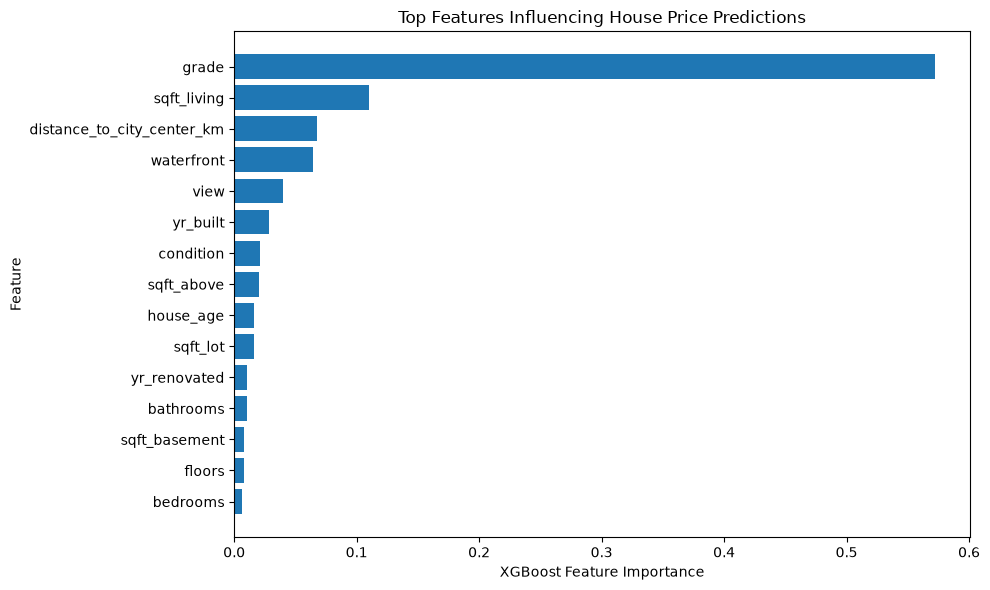

In [13]:
import matplotlib.pyplot as plt

top_features = feature_importance.head(15)

plt.figure(figsize=(10, 6))

plt.barh(top_features["Feature"][::-1],top_features["Importance"][::-1])

plt.xlabel("XGBoost Feature Importance")
plt.ylabel("Feature")
plt.title("Top Features Influencing House Price Predictions")

plt.tight_layout()
plt.show()

In [14]:
xgb_model_path = os.path.join(MODEL_DIR,"xgboost_baseline.pkl")

joblib.dump(xgb_model,xgb_model_path)

print("XGBoost model saved successfully:")
print(xgb_model_path)

XGBoost model saved successfully:
e:\AARAV\Infotact-DS-ML\Project-3-Geospatial-Valuation\models\xgboost_baseline.pkl


In [15]:
PREDICTION_DIR = os.path.join(DATA_DIR,"predictions")

os.makedirs(PREDICTION_DIR,exist_ok=True)

In [16]:
xgb_predictions_path = os.path.join(PREDICTION_DIR,"xgboost_predictions.csv")

xgb_predictions.to_csv(xgb_predictions_path,index=False)

print("XGBoost predictions saved:")
print(xgb_predictions_path)

XGBoost predictions saved:
e:\AARAV\Infotact-DS-ML\Project-3-Geospatial-Valuation\data\processed\week-2\predictions\xgboost_predictions.csv


In [17]:
comparison_path = os.path.join(DATA_DIR,"baseline_model_comparison.csv")

comparison.to_csv(comparison_path,index=False)

print("Baseline comparison saved:")
print(comparison_path)

Baseline comparison saved:
e:\AARAV\Infotact-DS-ML\Project-3-Geospatial-Valuation\data\processed\week-2\baseline_model_comparison.csv


In [18]:
print("=" * 65)
print("WEEK 2 – DAY 3 VALIDATION")
print("=" * 65)

print(f"Training records       : {len(X_train):,}")
print(f"Holdout records        : {len(X_test):,}")
print(f"Features used          : {X_train.shape[1]}")

print("\nFeature consistency    :", list(X_train.columns) == list(X_test.columns))

print("Missing values X_train:",X_train.isnull().sum().sum())

print("Missing values X_test :",X_test.isnull().sum().sum())

print("\nLinear Regression RMSE : "
      f"${linear_rmse:,.2f}")

print("XGBoost RMSE           : "
      f"${rmse_xgb:,.2f}")

print("\nLinear Regression MAPE : "
      f"{linear_mape:.2f}%")

print("XGBoost MAPE           : "
      f"{mape_xgb:.2f}%")

print("\nModel saved:")
print(xgb_model_path)

print("\nDay 3 completed successfully.")

WEEK 2 – DAY 3 VALIDATION
Training records       : 17,277
Holdout records        : 4,320
Features used          : 15

Feature consistency    : True
Missing values X_train: 0
Missing values X_test : 0

Linear Regression RMSE : $129,959.74
XGBoost RMSE           : $103,398.17

Linear Regression MAPE : 23.50%
XGBoost MAPE           : 17.31%

Model saved:
e:\AARAV\Infotact-DS-ML\Project-3-Geospatial-Valuation\models\xgboost_baseline.pkl

Day 3 completed successfully.
